In [73]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import cv2

In [74]:
base_dir = Path("images")

images = {}

for subdir in base_dir.iterdir():
    if subdir.is_dir():
        img_dict = {}
        for img_file in subdir.glob("*.[pj][pn]g"):  # matches .png and .jpg
            img_dict[img_file.name] = Image.open(img_file)
        images[subdir.name] = img_dict

print(f"Loaded {sum(len(v) for v in images.values())} images across {len(images)} categories.")

Loaded 10 images across 3 categories.


In [75]:
def print_pics(images_dict, cmap=None):
    if not images_dict:
        print("No images to display.")
        return

    difficulties = sorted(images_dict.keys())

    max_cols = max(len(v) for v in images_dict.values())
    fig, axes = plt.subplots(
        nrows=len(difficulties),
        ncols=max_cols,
        figsize=(3 * max_cols, 3 * len(difficulties))
    )

    if len(difficulties) == 1:
        axes = [axes]
    elif axes.ndim == 1:
        axes = [axes]

    for row_idx, diff in enumerate(difficulties):
        imgs = images_dict[diff]

        sorted_imgs = dict(sorted(imgs.items()))

        for col_idx, (img_name, img) in enumerate(sorted_imgs.items()):
            ax = axes[row_idx][col_idx]
            ax.imshow(img, cmap=cmap)
            ax.set_title(img_name, fontsize=8)
            ax.axis("off")

        for empty_ax in axes[row_idx][len(sorted_imgs):]:
            empty_ax.axis("off")

        axes[row_idx][0].set_ylabel(diff, rotation=0, size='large', labelpad=40, weight='bold')

    plt.tight_layout()
    plt.show()

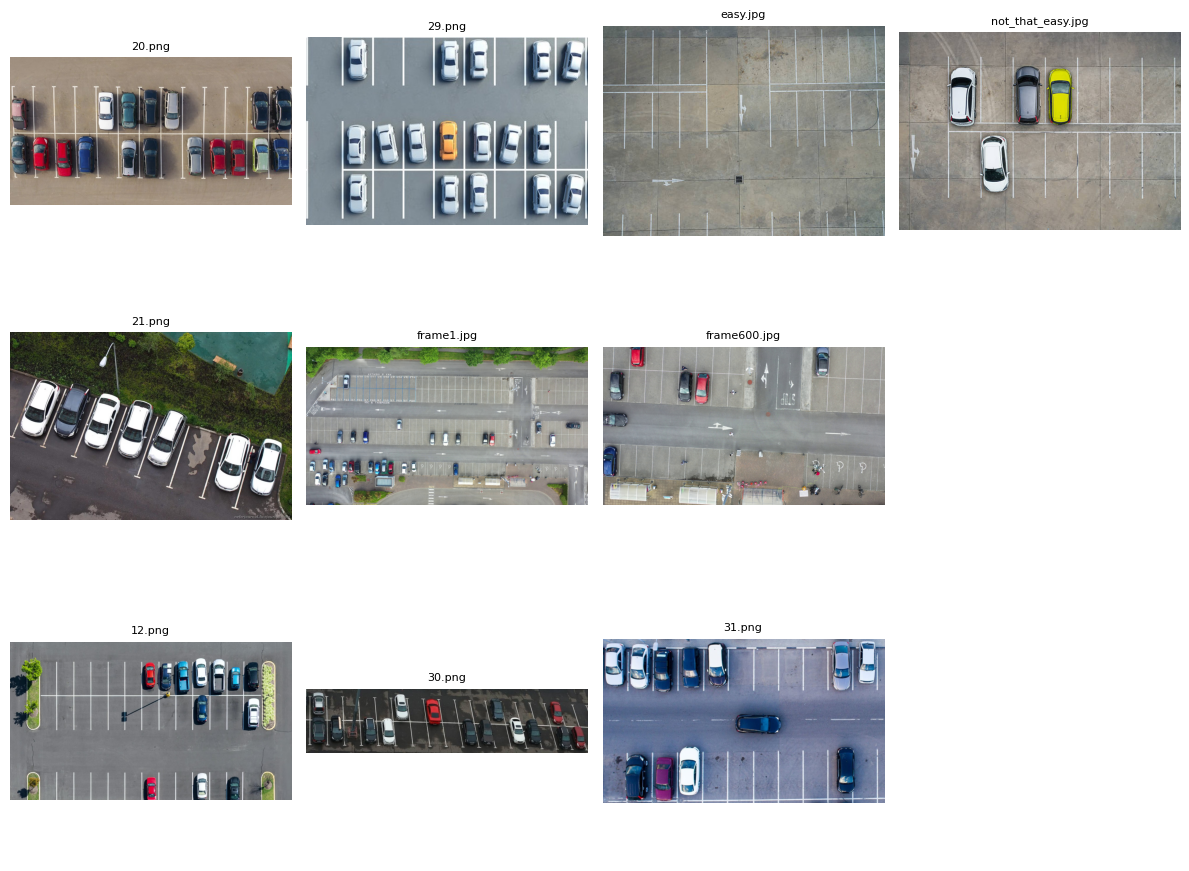

In [76]:
print_pics(images)

In [26]:
# A helper function to apply a transformation to the image array. takes in an input array, an output array, and a function
def apply_technique(input_dict, output_dict, func):
    """
    input_dict : dict
        Nested dict structured as {level: {image_name: image_array}}
    output_dict : dict (empty dict recommended)
        Where transformed results are written using the same nested structure.
    func : function
        Should accept (image, level_index, image_index)
        and return a transformed image.
    """
    output_dict.clear() # clear the output

    # iterate over the the array
    for set_idx, (level, img_set) in enumerate(input_dict.items()):
        new_level = {}

        for img_idx, (img_name, img) in enumerate(img_set.items()):
            new_level[img_name] = func(img, set_idx, img_idx)

        output_dict[level] = new_level

    return output_dict

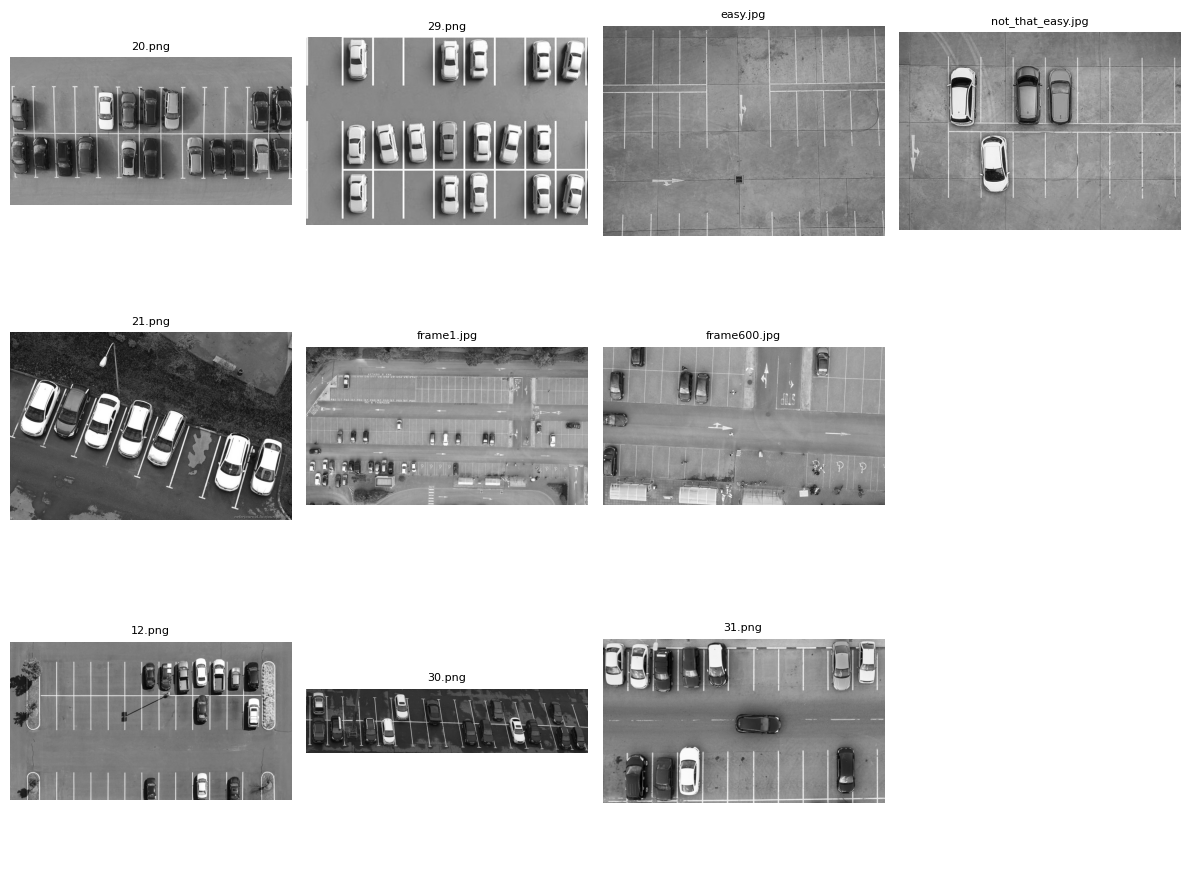

In [27]:
def convert_greyscale(img, level_idx, img_idx):

    img = np.array(img)

    # If image is already grayscale, return as is
    if img.ndim == 2:
        return img

    # Convert BGR or RGB to grayscale
    grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return grey

greyscale_results = {}
apply_technique(images, greyscale_results, convert_greyscale)
print_pics(greyscale_results, cmap='gray')

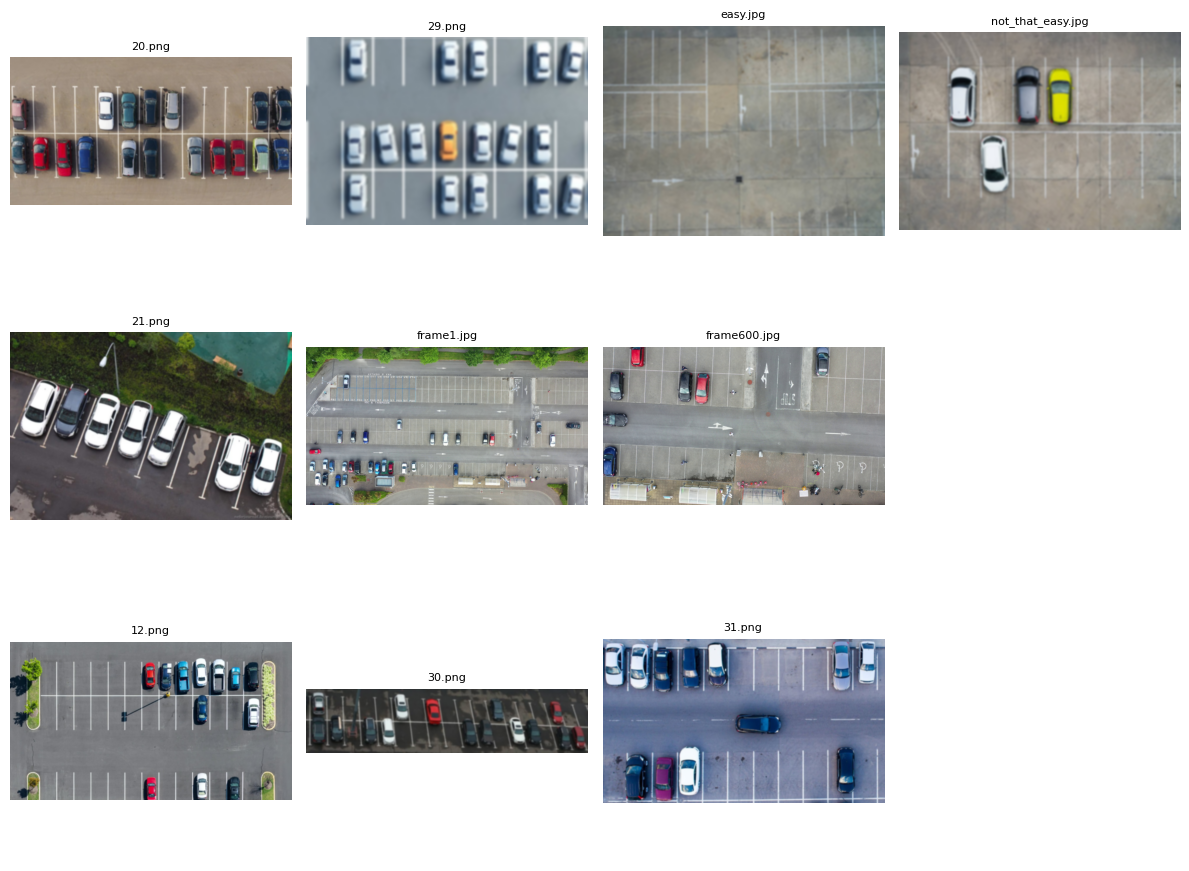

In [82]:
def blur_fn(img, level_idx, img_idx, ksize=9, sigma=2.0):

    img = np.array(img)

    blurred = cv2.GaussianBlur(img, (ksize, ksize), sigma)

    return Image.fromarray(blurred)

blurred_images = {}
apply_technique(images, blurred_images, blur_fn)
print_pics(blurred_images)

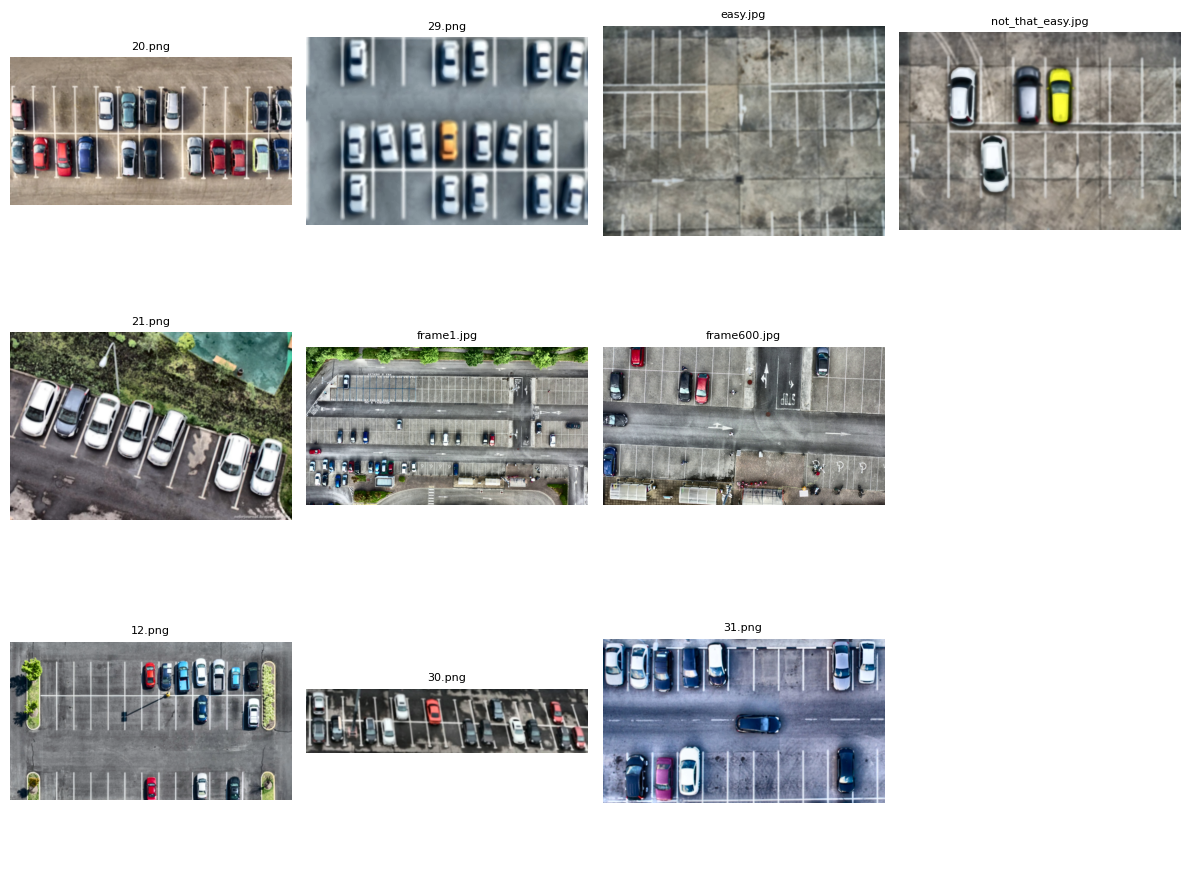

In [83]:
def enhance_contrast_fn(img, level_idx, img_idx, clip_limit=3.0, tile_size=8):
    """
    Apply CLAHE to improve local contrast before threshold masking.
    Returns a PIL RGB image.
    """
    # Convert PIL → NumPy
    if isinstance(img, Image.Image):
        img_np = np.array(img)
    else:
        img_np = img

    # Convert RGB → LAB (CLAHE works on L channel)
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)

    # Apply CLAHE only to the lightness channel
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile_size, tile_size))
    L_enhanced = clahe.apply(L)

    # Merge back to LAB → convert to RGB
    lab_enhanced = cv2.merge((L_enhanced, A, B))
    rgb_enhanced = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2RGB)

    return Image.fromarray(rgb_enhanced)

contrasted_images = {}
apply_technique(blurred_images, contrasted_images, enhance_contrast_fn)
print_pics(contrasted_images)

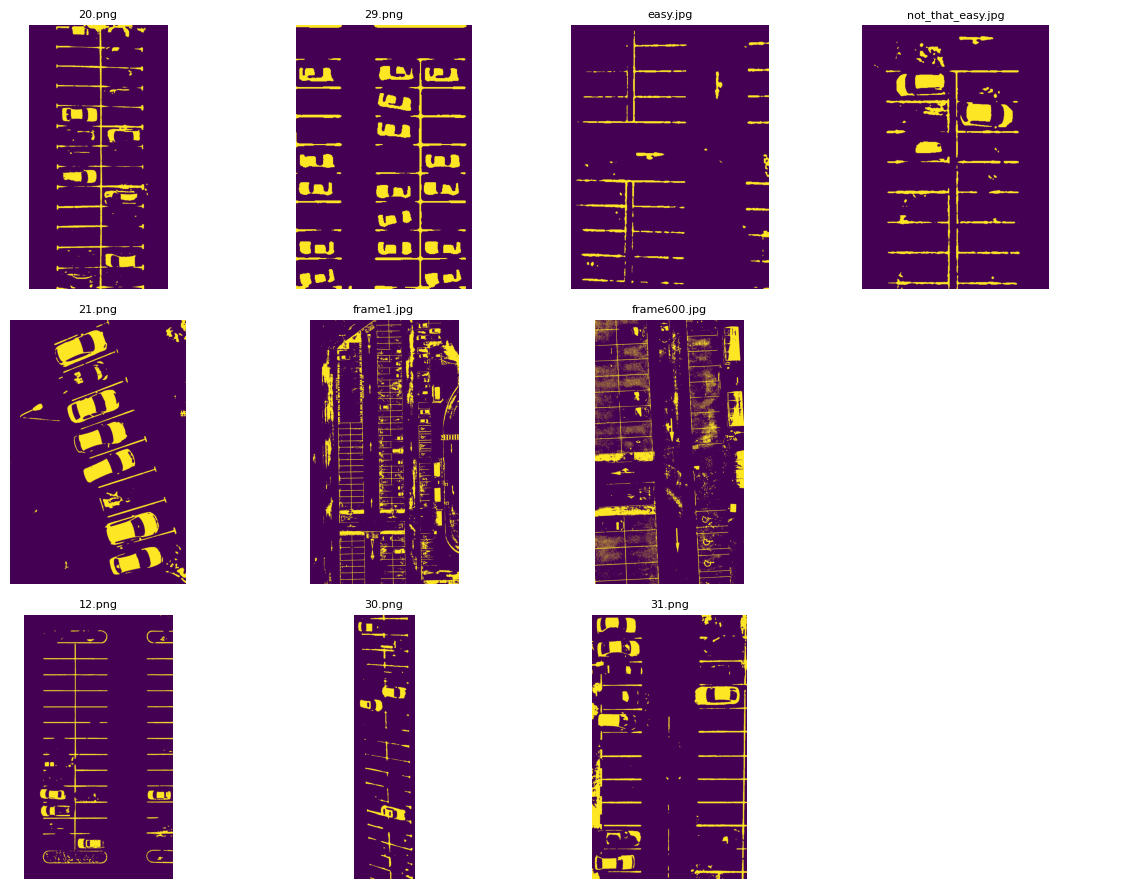

In [89]:
def threshold_mask_fn(img, level_idx, img_idx, threshold=175):
    img = img.convert("RGBA")
    data = np.array(img)

    r, g, b, a = data.T

    # Bright-pixel mask
    mask = (r > threshold) & (g > threshold) & (b > threshold)

    # Convert mask to grayscale PIL image
    mask_img = Image.fromarray((mask * 255).astype("uint8"))

    return mask_img

masked_images = {}
apply_technique(contrasted_images, masked_images, threshold_mask_fn)
print_pics(masked_images)

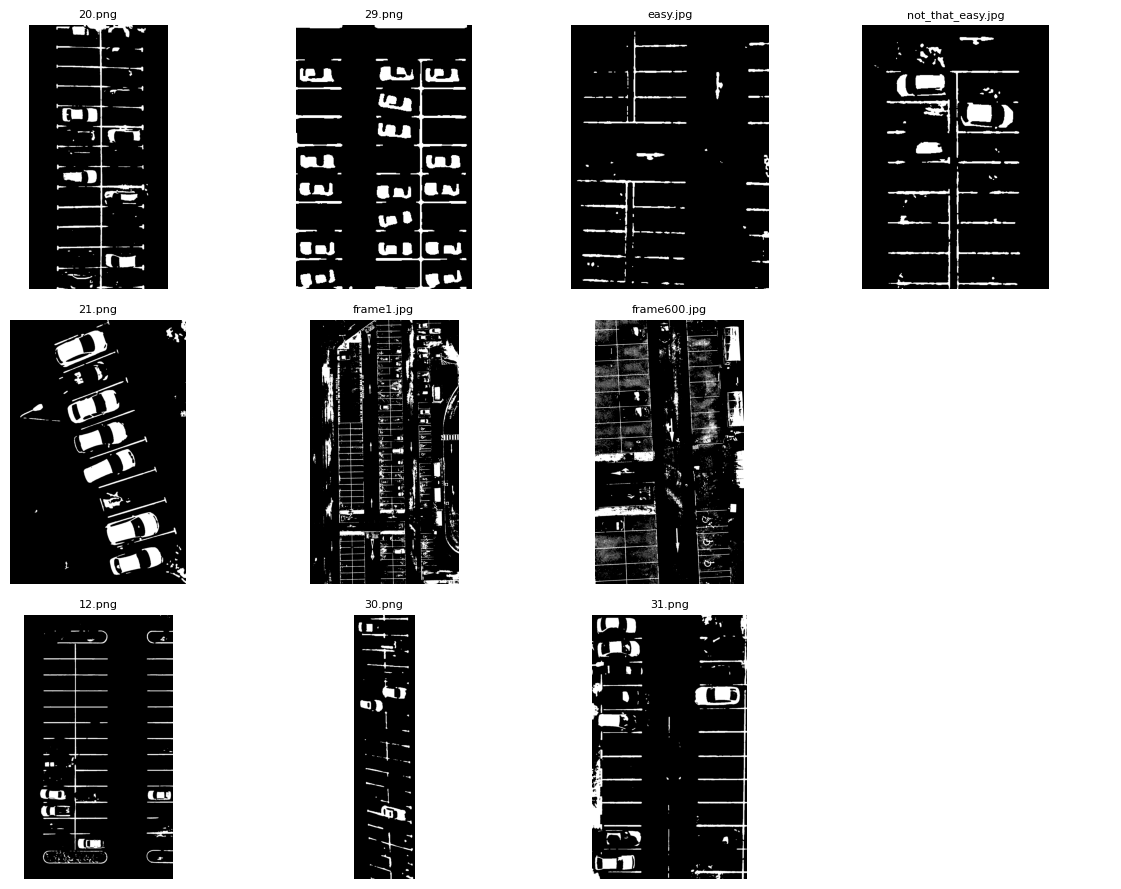

In [90]:
def morphological_opening(img, levl_idx, img_idx, kernel_size=2):

    img = np.array(img)

    mask = img.astype(np.uint8)


    kernel = np.ones((kernel_size, kernel_size), np.uint8)

    # Opening = erosion followed by dilation
    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return Image.fromarray(opened)

opened_images = {}
apply_technique(masked_images, opened_images, morphological_opening)
print_pics(opened_images, cmap='gray')

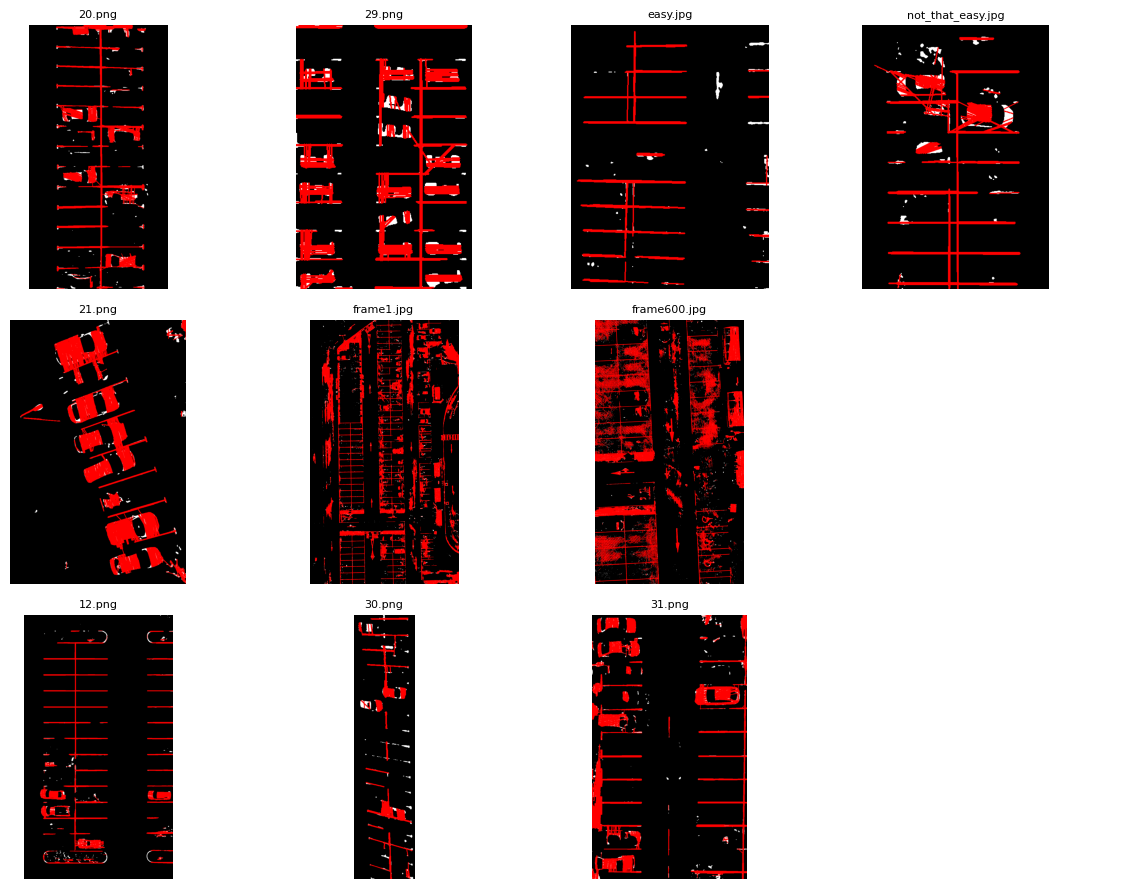

In [95]:
def hough_lines_fn(img, level_idx, img_idx,
                   min_line_length=20,
                   max_line_gap=20,
                   threshold=70):
    """
    img: PIL mask image (white=255, black=0)
    """

    # Convert PIL → NumPy array
    if isinstance(img, Image.Image):
        img = np.array(img)

    # Ensure grayscale uint8
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # HoughLinesP needs edges, not boolean mask
    edges = img.copy()  # mask is already binary edges

    # Run Hough Transform
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=threshold,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap
    )

    # Visualize lines
    line_img = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

    if lines is not None:
        for x1, y1, x2, y2 in lines.reshape(-1, 4):
            cv2.line(line_img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    return line_img

hough_results = {}
apply_technique(opened_images, hough_results, hough_lines_fn)
print_pics(hough_results)